In [2]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join('..', 'geoai', 'utils_ml')))

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from dl_ops import SegmentationDataset

import segmentation_models_pytorch as smp 
import torchmetrics

In [4]:
test_ds = SegmentationDataset(path_name='test')
test_dataloader = DataLoader(test_ds, batch_size=1, shuffle=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.FPN(
    encoder_name="se_resnext50_32x4d",
    encoder_weights=None,
    classes=6,
    activation="sigmoid",
)

# Load the weights
model.encoder.load_state_dict(
    torch.load("../trained_models/se_resnext50_32x4d-a260b3a4.pth")
)

C:\Users\Reginald\AppData\Local\Temp\ipykernel_13512\1349584044.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("../trained_models/se_resnext50_32x4d-a260b3a

In [5]:
# Load the model
model.load_state_dict(torch.load('trained_models/FPN_epochs_1_crossentropy_state_dict.pth'))

C:\Users\Reginald\AppData\Local\Temp\ipykernel_13512\336671283.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('trained_models/FPN_epoch

<All keys matched successfully>

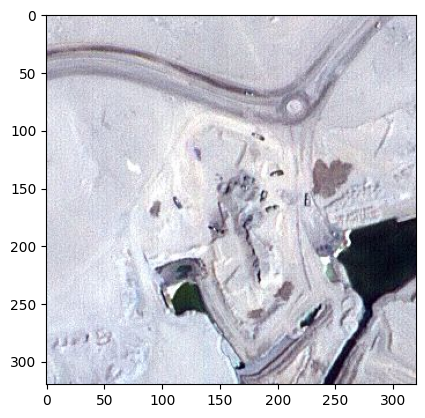

In [6]:
image_test, mask = next(iter(test_dataloader))
plt.imshow(np.transpose(image_test[0, :, :, :].cpu().numpy(), (1, 2, 0)))


Text(0.5, 1.0, 'Predicted Mask')

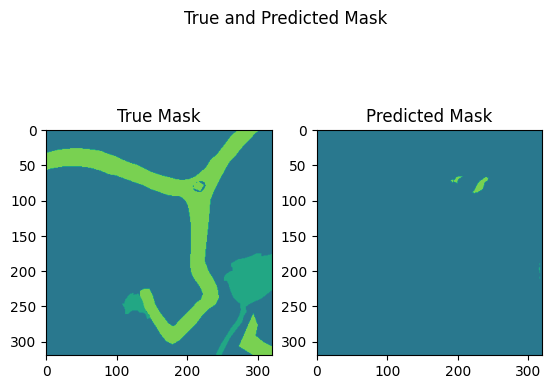

In [7]:
# create prediction
with torch.no_grad():
    image_test = image_test.float().to(DEVICE)
    output = model(image_test)

output_cpu = output.cpu().squeeze().numpy()
output_cpu = output_cpu.transpose((1, 2, 0))
output_cpu = output_cpu.argmax(axis=2)
output_cpu.shape

required_range = list(range(6))
output_cpu[0, 0] = 0
output_cpu[0, 1] = 1
output_cpu[0, 2] = 2
output_cpu[0, 3] = 3
output_cpu[0, 4] = 4
output_cpu[0, 5] = 5

mask[0, 0, 0] = 0
mask[0, 0, 1] = 1
mask[0, 0, 2] = 2
mask[0, 0, 3] = 3
mask[0, 0, 4] = 4
mask[0, 0, 5] = 5


fig, axs = plt.subplots(nrows=1, ncols=2)
fig.suptitle('True and Predicted Mask')
axs[0].imshow(mask[0, :, :])
axs[1].imshow(output_cpu)
axs[0].set_title("True Mask")
axs[1].set_title("Predicted Mask")
